In [1]:
import torch
print(torch.cuda.is_available())   # → True
print(torch.cuda.get_device_name(0))

True
NVIDIA GeForce RTX 4060


In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import re
import time
from datetime import datetime
import mujoco

import gymnasium as gym
from gymnasium.wrappers import RecordVideo
from gymnasium.envs.mujoco.humanoid_v5 import HumanoidEnv
from gymnasium.envs.registration import register
from IPython.display import HTML
from IPython.display import Video
from IPython.display import display, clear_output
from PIL import Image as PILImage

from stable_baselines3 import SAC, TD3
from stable_baselines3.common.noise import NormalActionNoise
from stable_baselines3.common.env_util import make_vec_env
from stable_baselines3.common.callbacks import CheckpointCallback

import glob

import os
#os.environ["MUJOCO_GL"] = "glfw"

pd.set_option('display.max_columns', None)

<p>
  <img src="Humanoid.png" alt="Humanoid" width="800">
</p>

In [3]:
def Record_Video(model, path_videos):
    os.makedirs(path_videos, exist_ok=True)
    
    record_env = gym.make("Humanoid-v5", render_mode="rgb_array")
    record_env = RecordVideo(record_env, path_videos , episode_trigger=lambda x: True)
    print("Recorded in: ", path_videos)

    obs, _ = record_env.reset()

    max_videos = 3
    k = 0
    for _ in range(2000):
        action, _ = model.predict(obs, deterministic=True)
        obs, reward, done, truncated, _ = record_env.step(action)

        if done or truncated:
            k += 1
            obs, _ = record_env.reset()
            if k >= max_videos:
                break

    record_env.close()
    
def extraer_timesteps(nombre: str) -> int | None:
    """Extrae el número entre 'final_' y el siguiente '_'."""
    match = re.search(r'final_(\d+)(?:_|$)', nombre)
    return int(match.group(1)) if match else None

Funcion step de mi enviroment:

    def step(self, action):
        xy_position_before = mass_center(self.model, self.data)
        self.do_simulation(action, self.frame_skip)
        xy_position_after = mass_center(self.model, self.data)

        xy_velocity = (xy_position_after - xy_position_before) / self.dt
        x_velocity, y_velocity = xy_velocity

        observation = self._get_obs()
        reward, reward_info = self._get_rew(x_velocity, action)
        terminated = (not self.is_healthy) and self._terminate_when_unhealthy
        info = {
            "x_position": self.data.qpos[0],
            "y_position": self.data.qpos[1],
            "tendon_length": self.data.ten_length,
            "tendon_velocity": self.data.ten_velocity,
            "distance_from_origin": np.linalg.norm(self.data.qpos[0:2], ord=2),
            "x_velocity": x_velocity,
            "y_velocity": y_velocity,
            **reward_info,
        }

        if self.render_mode == "human":
            self.render()
        # truncation=False as the time limit is handled by the `TimeLimit` wrapper added during `make`
        return observation, reward, terminated, False, info

    def _get_rew(self, x_velocity: float, action):
        forward_reward = self._forward_reward_weight * x_velocity
        healthy_reward = self.healthy_reward
        rewards = forward_reward + healthy_reward

        ctrl_cost = self.control_cost(action)
        contact_cost = self.contact_cost
        costs = ctrl_cost + contact_cost

        reward = rewards - costs

        reward_info = {
            "reward_survive": healthy_reward,
            "reward_forward": forward_reward,
            "reward_ctrl": -ctrl_cost,
            "reward_contact": -contact_cost,
        }

        return reward, reward_info

In [4]:
# 1. Crear entorno y acceder a la clase base (sin wrappers)
env = gym.make("Humanoid-v5", render_mode="rgb_array", ctrl_cost_weight= 0.3, forward_reward_weight=3)
base = env.unwrapped

print("🔹 CLASE:", type(base).__name__)
print("🔹 OBSERVATION SPACE:", base.observation_space)
print("🔹 ACTION SPACE:", base.action_space)

# 2. Listar atributos internos (evitamos métodos y privados)
print("\n📦 ATRIBUTOS INTERNOS:")
for key in sorted(vars(base)):
    if not key.startswith('_'):
        val = getattr(base, key)
        # Truncar valores largos para que la salida sea legible
        if hasattr(val, '__len__') and len(val) > 20:
            val = f"<{type(val).__name__} shape={getattr(val, 'shape', len(val))}>"
        elif isinstance(val, float):
            val = f"{val:.4f}"
        print(f"  {key}: {val}")

# 3. Búsqueda enfocada en parámetros de reward/costo
print("\n🎯 PARÁMETROS RELACIONADOS CON REWARDS/COSTOS:")
keywords = ['weight', 'reward', 'cost', 'bonus', 'penalty', 'scale', 'target']
found = False
for key in vars(base):
    print("key: ", key)
    if any(k in key.lower() for k in keywords):
        found = True
        #print(f"  {key}: {getattr(base, key)}")
    print(f"  {key}: {getattr(base, key)}")
if not found:
    print("  ⚠️ No se encontraron atributos directos. En v5 pueden estar en self._reward_spec o calcularse en step().")

🔹 CLASE: HumanoidEnv
🔹 OBSERVATION SPACE: Box(-inf, inf, (348,), float64)
🔹 ACTION SPACE: Box(-0.4, 0.4, (17,), float32)

📦 ATRIBUTOS INTERNOS:
  action_space: Box(-0.4, 0.4, (17,), float32)
  camera_id: None
  camera_name: None
  data: <mujoco._structs.MjData object at 0x000002AFF19A2F70>
  frame_skip: 5
  fullpath: <str shape=95>
  height: 480
  init_qpos: <ndarray shape=(24,)>
  init_qvel: <ndarray shape=(23,)>
  metadata: {'render_modes': ['human', 'rgb_array', 'depth_array', 'rgbd_tuple'], 'render_fps': 67}
  model: <mujoco._structs.MjModel object at 0x000002AFFF226170>
  mujoco_renderer: <gymnasium.envs.mujoco.mujoco_rendering.MujocoRenderer object at 0x000002AFFFA023C0>
  observation_space: Box(-inf, inf, (348,), float64)
  observation_structure: {'skipped_qpos': 2, 'qpos': 22, 'qvel': 23, 'cinert': 130, 'cvel': 78, 'qfrc_actuator': 17, 'cfrc_ext': 78, 'ten_length': 0, 'ten_velocity': 0}
  render_mode: rgb_array
  spec: EnvSpec(id='Humanoid-v5', entry_point='gymnasium.envs.mujoc

In [5]:
import inspect

print(inspect.getsource(base.step))

    def step(self, action):
        xy_position_before = mass_center(self.model, self.data)
        self.do_simulation(action, self.frame_skip)
        xy_position_after = mass_center(self.model, self.data)

        xy_velocity = (xy_position_after - xy_position_before) / self.dt
        x_velocity, y_velocity = xy_velocity

        observation = self._get_obs()
        reward, reward_info = self._get_rew(x_velocity, action)
        terminated = (not self.is_healthy) and self._terminate_when_unhealthy
        info = {
            "x_position": self.data.qpos[0],
            "y_position": self.data.qpos[1],
            "tendon_length": self.data.ten_length,
            "tendon_velocity": self.data.ten_velocity,
            "distance_from_origin": np.linalg.norm(self.data.qpos[0:2], ord=2),
            "x_velocity": x_velocity,
            "y_velocity": y_velocity,
            **reward_info,
        }

        if self.render_mode == "human":
            self.render()
        # truncation

In [6]:
# para funcionamiento en .py


import custom_humanoid

env = gym.make("CustomHumanoid-v0")
obs, info = env.reset()

init
left knee:  17  right knee:  13


In [ ]:
# policy = elegir las recompensas
# "basic" sin ninguna modificacion de politicas
# velocity => reward = ** * velocity^2
# knees => custom rewards for knees to move
policy = "knees"#"velocity"
lines = 8

if policy == "velocity":
    env = make_vec_env(
                        "Humanoid-v5",
                        n_envs=lines,
                        env_kwargs={"forward_reward_weight": 3.0},  
                        seed=42
)
elif policy == "knees":
    print("Entenamiento Custom version kness")
    env = make_vec_env("CustomHumanoid-v0", n_envs=lines)        
else:
    print("Entenamiento Basico")
    env = make_vec_env("Humanoid-v5", n_envs=lines)

# Configuiraciones: load determina si se carga o no, checkpoint que tipo de carga, y train_* son para los modelos
load = False             # para reanudar entrenamiento             
checkpoint = False       # para reanuder entrenamiento desde checkpoint
train_SAC = True        # para entrenar con SAC
train_TD3 = False       # para entrenar con TD3

time_steps = 10_000_000
eval_parts = 6
part = time_steps / eval_parts

checkpoint_dir = "./checkpoints/"
os.makedirs(checkpoint_dir, exist_ok=True)

sac_dir = "./sac_models/"
os.makedirs(sac_dir, exist_ok=True)

td3_dir = "./td3_models/"
os.makedirs(td3_dir, exist_ok=True)

fecha = datetime.now().strftime("%Y%m%d")

checkpoint_callback = CheckpointCallback(
    save_freq=100_000,
    save_path=checkpoint_dir,
    name_prefix="sac_ckp" if train_SAC else "td3_ckp"
)
""" los primeros los hice con:
           model = SAC(
            "MlpPolicy", env, verbose=0,
            learning_rate=3e-4, buffer_size=1_000_000,
            batch_size=256, tau=0.005, gamma=0.99
        ) 

"""

# ID del entrenamiento
id = 1000

gamma = 0.92
tau = 0.005

sufijo = f"_{id}_{fecha}_{policy}_{lines}_g{int(gamma*100)}t{int(tau*1000)}"

model = None

try:
    if train_SAC and not load:
        print("🚀 Iniciando entrenamiento SAC...")
        model = SAC(                    
            "MlpPolicy", env, verbose=0,
            learning_rate=3e-4, buffer_size=1_000_000,
            batch_size=256, tau=tau, gamma=gamma
        )
        
        for i in range(eval_parts):
            print("i: ", i)
            model.learn(total_timesteps=part, progress_bar=True,)
                        #callback=checkpoint_callback)
            print("guardar checkpoint")
            model.save(checkpoint_dir + "sac_ckp_" + str( i * part) + sufijo)
            print("videos de ")
            Record_Video(model, (checkpoint_dir + "/videos_sac_" + str( i * part) + sufijo))      
                  
        print("Model_save")
        model.save(sac_dir + "sac_humanoid_final_" + str(time_steps) + sufijo)
        print("Model_saved")

    elif train_TD3 and not load:
        print("🚀 Iniciando entrenamiento TD3...")
        n_actions = env.action_space.shape[0]
        action_noise = NormalActionNoise(mean=np.zeros(n_actions), sigma=0.1 * np.ones(n_actions))
        model = TD3(
            "MlpPolicy", env, verbose=0,
            learning_rate=3e-4, buffer_size=1_000_000,
            batch_size=256, tau=0.005, gamma=0.99,
            action_noise=action_noise, policy_delay=2,
            target_policy_noise=0.2, target_noise_clip=0.5
        )
        
        for i in range(eval_parts):
            print("i: ", i)
            model.learn(total_timesteps=part, progress_bar=True,)
                        #callback=checkpoint_callback)
            model.save(checkpoint_dir + "td3_ckp_" + str( i * part) + sufijo)
            
            Record_Video(model, (checkpoint_dir + "/videos_td3_" + str( i * part) + sufijo))            
            
        model.save(td3_dir + "td3_humanoid_final_" + str(time_steps) + sufijo)

    else:
        print("📂 Entrando en modo reanudacion de entrenamiento")
        
        if train_SAC:
            if (checkpoint == True):
                # -----------------------probar
                print("Recuperando checkpoint")
                # Entra al modo recuperacion , pero desde el checkpoint, esta parte esta para recuperar algun entrenamiento que no este completo
                
                # comprueba y adquiere los archivos de checkpoint
                ckpt_files = glob.glob("./checkpoints/sac_ckp_*_steps.zip")
                if not ckpt_files:
                    raise FileNotFoundError("No se encontraron checkpoints en ./checkpoints/")
                
                # elige el de mayor numero de steps
                latest_ckpt = max(ckpt_files, key=lambda f: int(re.search(r'(\d+)_steps\.zip$', f).group(1)))
                print("Debug latest chkpoint: ", latest_ckpt)
            
                model = SAC.load(latest_ckpt, env=env)
                
                print("✅ Reanudando entrenamiento desde checkpoint...")
                
                model.learn(
                    total_timesteps=time_steps, 
                    progress_bar=True, 
                    callback=checkpoint_callback,
                    reset_num_timesteps=False 
                )
                
                model.save(sac_dir + "sac_humanoid_final_" + str(time_steps) + sufijo)
            else:
                # -----------------------probar
                print("Cargando modelo")
                                
                model = SAC.load(sac_dir + "sac_humanoid_final_20000000_20260516_knees_8_g95t5")
                resume_time_steps = extraer_timesteps("sac_humanoid_final_20000000_20260516_knees_8_g95t5")
                part = (time_steps - resume_time_steps) / eval_parts
                model.set_env(env)
                
                print("✅ Reanudando entrenamiento desde modelo entrenado...")
                
                
                
                for i in range(eval_parts):
                    print("i: ", i)
                    model.learn(total_timesteps=part, 
                                progress_bar=True,
                                reset_num_timesteps=False,
                                )

                    model.save(checkpoint_dir + "sac_ckp_" + str( i * part + resume_time_steps) + sufijo)
                    
                    Record_Video(model, (checkpoint_dir + "/videos_sac_" + str( i * part + resume_time_steps) + sufijo))            
                    
                model.save(sac_dir + "sac_humanoid_final_" + str(time_steps) + sufijo)
        else:
            # -----------------------probar
            print("📂 Cargando modelo ...")
            
            
            #model = TD3.load("td3_humanoid_final")


except KeyboardInterrupt:
    print("\n⏹️ Entrenamiento interrumpido manualmente.")
    model.save(("sac_humanoid_last"  + f"_{fecha}") if train_SAC else ("td3_humanoid_last"  + f"_{fecha}"))
    print("💾 Estado guardado. Ejecuta de nuevo con `load = True` para continuar.")

finally:
    env.close()
    print("🏁 Entorno cerrado.")

Entenamiento Custom version kness
init
init
init
init
init
init
init
init
🚀 Iniciando entrenamiento SAC...


Output()

i:  0
left knee:  17  right knee:  13
left knee:  17  right knee:  13
left knee:  17  right knee:  13
left knee:  17  right knee:  13
left knee:  17  right knee:  13
left knee:  17  right knee:  13
left knee:  17  right knee:  13
left knee:  17  right knee:  13


# Creacion Videos

In [ ]:
path_videos = "./videos_trained"

env = gym.make("Humanoid-v5", render_mode="rgb_array")
env = RecordVideo(env, path_videos, episode_trigger=lambda x: True)

obs, _ = env.reset()

for k in range(2000):
    action, _ = model.predict(obs, deterministic=True)
    obs, reward, done, truncated, _ = env.step(action)
    
    qpos = env.unwrapped.data.qpos
    l_knee_angle = obs[15]#qpos[10]
    r_knee_angle = qpos[11]

    #print(k , f" Rodilla izquierda: {l_knee_angle:.3f} rad")
    #print(k , f" --------Rodilla derecha:   {r_knee_angle:.3f} rad")

    if done or truncated:
        #print("------------------------------------Siguiente--------------------------------------")
        obs, _ = env.reset()
        break

env.close()

c:\Users\Alfonso\Documents\TFM\venv\Lib\site-packages\gymnasium\wrappers\rendering.py:293: UserWarning: WARN: Overwriting existing videos at c:\Users\Alfonso\Documents\TFM\videos_trained folder (try specifying a different `video_folder` for the `RecordVideo` wrapper if this is not desired)
  logger.warn(


In [ ]:
# Busca el primer vídeo generado
video_file = []
for file in os.listdir(path_videos):
    print("file: ", file)
    if file.endswith(".mp4"):
        video_file.append( os.path.join(path_videos, file))

file:  rl-video-episode-0.mp4
file:  rl-video-episode-1.mp4
file:  rl-video-episode-2.mp4


In [ ]:
Video(video_file[0], embed=True)

# visualizacion en el notebook

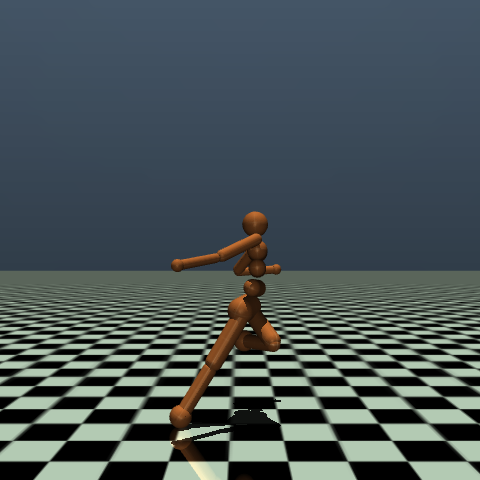

In [ ]:


# 1. Crear entorno con renderizado en formato imagen
env = gym.make("Humanoid-v5", render_mode="rgb_array")
obs, info = env.reset()

# 2. Bucle de simulación
for step in range(300):  # Ajusta según necesites (300 ~ 5-6 segundos)
    action, _ = model.predict(obs, deterministic=True)#env.action_space.sample()  # ← Reemplaza por tu política/agente
    obs, reward, terminated, truncated, info = env.step(action)

    frame = env.render()
    if frame is not None:
        clear_output(wait=True)  # Limpia la celda sin parpadeo
        display(PILImage.fromarray(frame))

    if terminated or truncated:
        obs, info = env.reset()

    time.sleep(0.03)  # Controla la velocidad de reproducción

env.close()